<a href="https://colab.research.google.com/github/KIRANRW9/Airbnb-EDA/blob/repo-exercise/Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(74111, 29)


/tmp/ipython-input-2030444049.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
/tmp/ipython-input-2030444049.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Dataset shape after cleaning: (72651, 30)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 72651 entries, 0 to 74110
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      72651 non-null  int64         
 1   log_price               72651 non-null  float64       
 2   property_type           72651 non-null  object        
 3   room_type               72651 non-null  object        
 4   amenities               72651 non-null  object        
 5   accommodates            72651 non-null  int64         
 6   bathrooms               72651 non-null  float64       
 7   bed_type                72651 non-null  object        
 8   cancellation_policy     72651 non-null  object        
 9   cleaning_fee            72651 non-null  bool          
 10  city                    72651 non-null  object        
 11  description             72651 non-null  object        

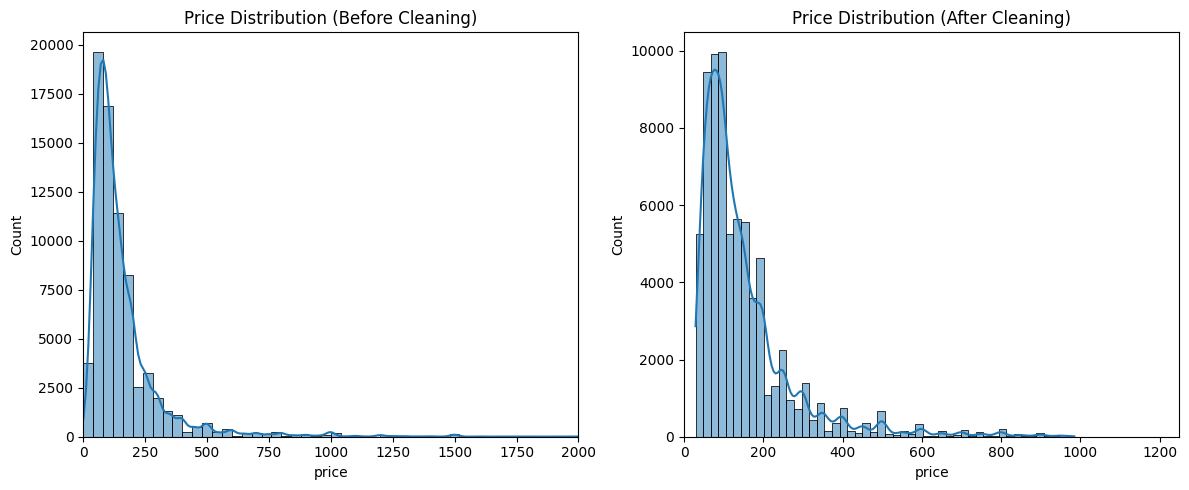

/tmp/ipython-input-2030444049.py:73: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="room_type", y="price", data=df, estimator=np.mean, ci=None)


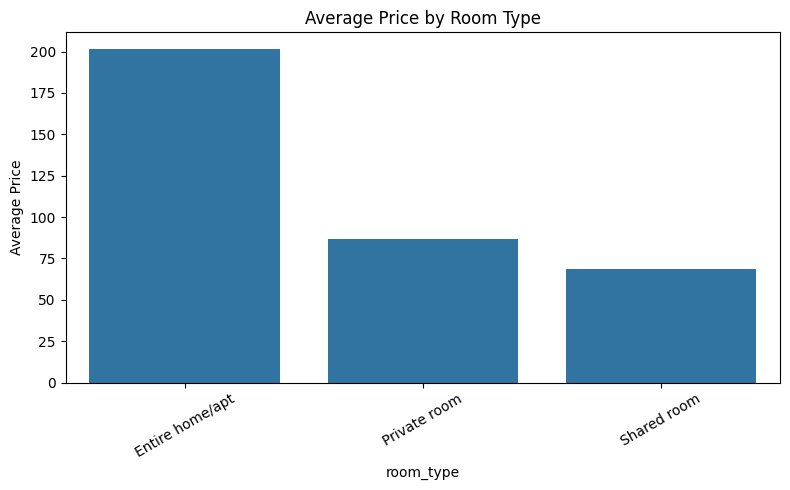

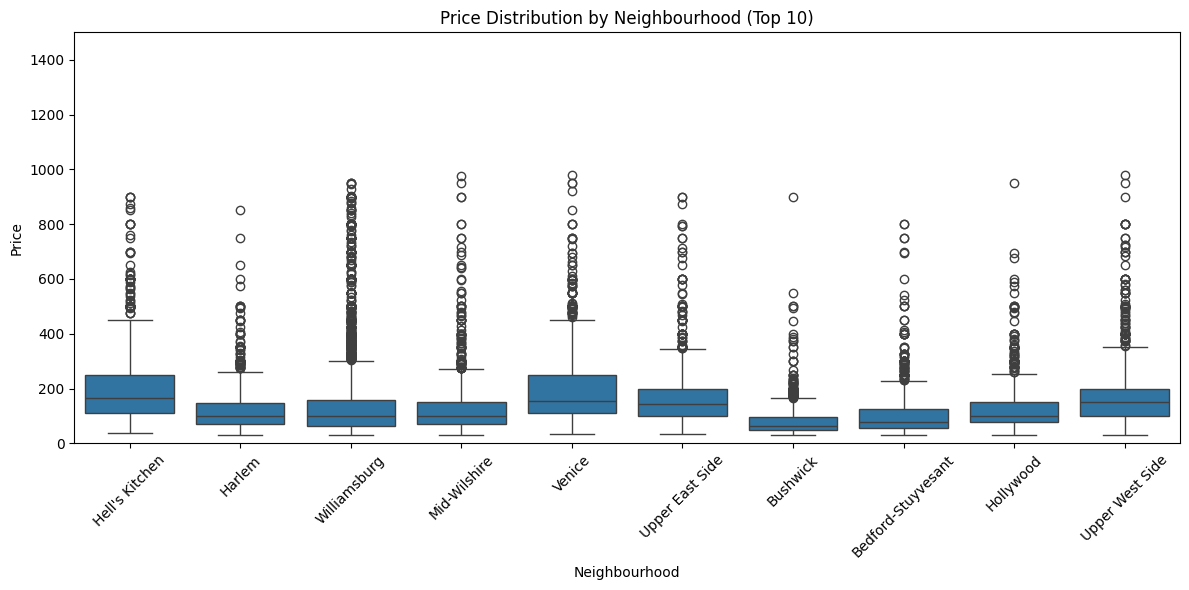

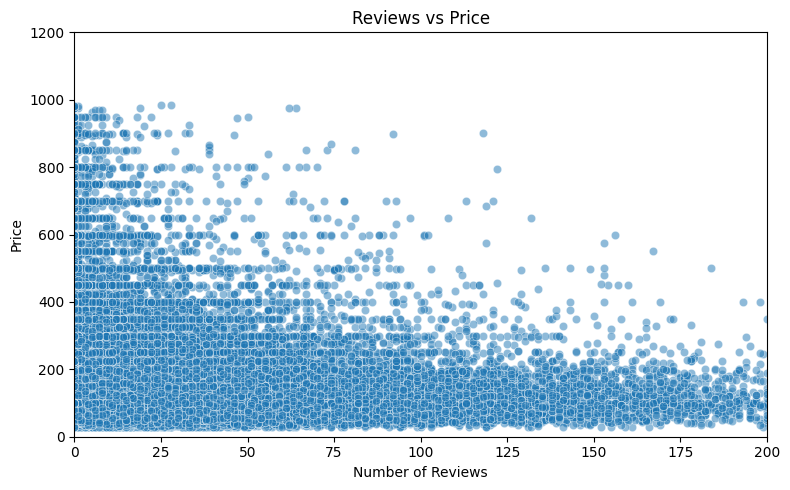

✅ Data cleaned and key insights visualized successfully.


In [ ]:
"""Airbnb Data Cleaning & EDA Project"""

# 1️. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2️. Load Dataset
df_original = pd.read_csv(
    r"/content/drive/MyDrive/Airbnb/Airbnb_Data.csv",
    on_bad_lines='skip',
    engine='python'
)
df = df_original.copy()

print(df.shape)


# 3️. Data Cleaning
# Handle missing values
df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)
df['beds'].fillna(df['beds'].median(), inplace=True)
df['review_scores_rating'].fillna(df['review_scores_rating'].median(), inplace=True)
df['neighbourhood'].fillna(df['neighbourhood'].mode()[0], inplace=True)
df['host_response_rate'].fillna("Unknown", inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert dates
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Handle outliers in log_price
lower, upper = df['log_price'].quantile([0.01, 0.99])
df = df[(df['log_price'] >= lower) & (df['log_price'] <= upper)]

# Add price column
df_original['price'] = np.exp(df_original['log_price'])
df['price'] = np.exp(df['log_price'])

# 4️. Dataset Summary
print("Dataset shape after cleaning:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing values after cleaning:")
print(df.isnull().sum().head(10))

# 5️. Exploratory Data Analysis (EDA)

# Price Distribution Before vs After Cleaning
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_original['price'], bins=50, kde=True)
plt.xlim(0, 2000)
plt.title("Price Distribution (Before Cleaning)")

plt.subplot(1,2,2)
sns.histplot(df['price'], bins=50, kde=True)
plt.xlim(0, 1250)
plt.title("Price Distribution (After Cleaning)")
plt.tight_layout()
plt.savefig("before_after_price.png", dpi=300)
plt.show()

# Average Price by Room Type
plt.figure(figsize=(8,5))
sns.barplot(x="room_type", y="price", data=df, estimator=np.mean, ci=None)
plt.title("Average Price by Room Type")
plt.ylabel("Average Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("room_type_price.png", dpi=300)
plt.show()

# Price Distribution by Top 10 Neighbourhoods
top_neigh = df['neighbourhood'].value_counts().nlargest(10).index
plt.figure(figsize=(12,6))
sns.boxplot(x="neighbourhood", y="price", data=df[df['neighbourhood'].isin(top_neigh)])
plt.title("Price Distribution by Neighbourhood (Top 10)")
plt.ylabel("Price")
plt.xlabel("Neighbourhood")
plt.xticks(rotation=45)
plt.ylim(0, 1500)
plt.tight_layout()
plt.savefig("neighbourhood_boxplot.png", dpi=300)
plt.show()

# Reviews vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x="number_of_reviews", y="price", data=df, alpha=0.5)
plt.title("Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.ylim(0, 1200)
plt.xlim(0, 200)
plt.tight_layout()
plt.savefig("reviews_price.png", dpi=300)
plt.show()

# 6️. Conclusion
print("✅ Data cleaned and key insights visualized successfully.")
